In [37]:
import os
import re
import csv
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
from pathlib import Path

# Project directory
PROJECT_DIR = Path.cwd().parent

# Dataset directory
DATA_DIR = PROJECT_DIR / "data" / "sentiment140"

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"

print("Project directory:", PROJECT_DIR)
print("Training file:", TRAIN_PATH)
print("Testing file:", TEST_PATH)

print("\nFiles found:")
print("Train:", TRAIN_PATH.exists())
print("Test :", TEST_PATH.exists())

Project directory: c:\Users\10cav\Downloads\multilingual-sentiment-analysis
Training file: c:\Users\10cav\Downloads\multilingual-sentiment-analysis\data\sentiment140\train_data.csv
Testing file: c:\Users\10cav\Downloads\multilingual-sentiment-analysis\data\sentiment140\test_data.csv

Files found:
Train: True
Test : True


In [6]:
def inspect_csv(file_path, num_rows=5):
    print("=" * 70)
    print(f"FILE: {file_path.name}")
    print("=" * 70)

    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)

        for i, row in enumerate(reader):
            print(f"\nRow {i + 1}:")
            print(row)

            if i >= num_rows - 1:
                break


inspect_csv(TRAIN_PATH)

FILE: train_data.csv

Row 1:
['sentence', 'sentiment']

Row 2:
['awww that s a bummer you shoulda got david carr of third day to do it d', '0']

Row 3:
['is upset that he can t update his facebook by texting it and might cry as a result school today also blah', '0']

Row 4:
['i dived many times for the ball managed to save the rest go out of bounds', '0']

Row 5:
['my whole body feels itchy and like its on fire', '0']


In [8]:
inspect_csv(TEST_PATH)

FILE: test_data.csv

Row 1:
['sentence', 'sentiment']

Row 2:
['i loooooooovvvvvveee my kindle not that the dx is cool but the is fantastic in its own right', '1']

Row 3:
['reading my kindle love it lee childs is good read', '1']

Row 4:
['ok first assesment of the kindle it fucking rocks', '1']

Row 5:
['you ll love your kindle i ve had mine for a few months and never looked back the new big one is huge no need for remorse', '1']


In [9]:
train_preview = pd.read_csv(
    TRAIN_PATH,
    header=None,
    nrows=10,
    encoding="utf-8",
    encoding_errors="replace"
)

test_preview = pd.read_csv(
    TEST_PATH,
    header=None,
    nrows=10,
    encoding="utf-8",
    encoding_errors="replace"
)

print("Training data shape of preview:", train_preview.shape)
print("Testing data shape of preview :", test_preview.shape)

print("\nTraining preview:")
display(train_preview)

print("\nTesting preview:")
display(test_preview)

Training data shape of preview: (10, 2)
Testing data shape of preview : (10, 2)

Training preview:


,0,1
0,sentence,sentiment
1,awww that s a bummer you shoulda got david car...,0
2,is upset that he can t update his facebook by ...,0
3,i dived many times for the ball managed to sav...,0
4,my whole body feels itchy and like its on fire,0
5,no it s not behaving at all i m mad why am i h...,0
6,not the whole crew,0
7,need a hug,0
8,hey long time no see yes rains a bit only a bi...,0
9,nope they didn t have it,0



Testing preview:


,0,1
0,sentence,sentiment
1,i loooooooovvvvvveee my kindle not that the dx...,1
2,reading my kindle love it lee childs is good read,1
3,ok first assesment of the kindle it fucking rocks,1
4,you ll love your kindle i ve had mine for a fe...,1
5,fair enough but i have the kindle and i think ...,1
6,no it is too big i m quite happy with the kindle,1
7,fuck this economy i hate aig and their non loa...,0
8,jquery is my new best friend,1
9,loves twitter,1


In [10]:
def check_possible_header(file_path):
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        first_line = f.readline().strip()

    print("First line of file:")
    print(first_line)

    header_keywords = [
        "text", "tweet", "sentiment", "target",
        "label", "id", "date", "user"
    ]

    found_keywords = [
        word for word in header_keywords
        if word.lower() in first_line.lower()
    ]

    print("\nPossible header keywords found:", found_keywords)

    if found_keywords:
        print("The first line may contain column names.")
    else:
        print("The first line probably contains actual data.")


check_possible_header(TRAIN_PATH)

First line of file:
sentence,sentiment

Possible header keywords found: ['sentiment']
The first line may contain column names.


In [11]:
def load_sentiment_data(file_path):
    """
    Loads a CSV while initially treating the first row as data.
    The actual structure will be examined before assigning column names.
    """

    df = pd.read_csv(
        file_path,
        header=None,
        encoding="utf-8",
        encoding_errors="replace"
    )

    return df


train_raw = load_sentiment_data(TRAIN_PATH)
test_raw = load_sentiment_data(TEST_PATH)

print("Training shape:", train_raw.shape)
print("Testing shape :", test_raw.shape)

Training shape: (1523976, 2)
Testing shape : (360, 2)


In [12]:
print("Number of training columns:", train_raw.shape[1])

print("\nTraining columns:")
for i, column in enumerate(train_raw.columns):
    print(f"{i}: {column}")

print("\nFirst 5 training rows:")
display(train_raw.head())

Number of training columns: 2

Training columns:
0: 0
1: 1

First 5 training rows:


,0,1
0,sentence,sentiment
1,awww that s a bummer you shoulda got david car...,0
2,is upset that he can t update his facebook by ...,0
3,i dived many times for the ball managed to sav...,0
4,my whole body feels itchy and like its on fire,0


In [13]:
print("TRAINING DATA")
print("=" * 50)

print("Rows:", train_raw.shape[0])
print("Columns:", train_raw.shape[1])

print("\nMemory usage:")
train_raw.info()

TRAINING DATA
Rows: 1523976
Columns: 2

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1523976 entries, 0 to 1523975
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   0       1523976 non-null  object
 1   1       1523976 non-null  object
dtypes: object(2)
memory usage: 23.3+ MB


In [14]:
print("TEST DATA")
print("=" * 50)

print("Rows:", test_raw.shape[0])
print("Columns:", test_raw.shape[1])

print("\nMemory usage:")
test_raw.info()

TEST DATA
Rows: 360
Columns: 2

Memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       360 non-null    object
 1   1       360 non-null    object
dtypes: object(2)
memory usage: 5.8+ KB


In [15]:
print("Missing values in training data:")
display(train_raw.isnull().sum())

print("\nMissing values in test data:")
display(test_raw.isnull().sum())

Missing values in training data:


0    0
1    0
dtype: int64


Missing values in test data:


0    0
1    0
dtype: int64

In [16]:
for column in train_raw.columns:
    print(f"\nColumn {column}")
    print("Unique values:", train_raw[column].nunique())

    if train_raw[column].nunique() <= 20:
        print(train_raw[column].value_counts())


Column 0
Unique values: 1519833

Column 1
Unique values: 4
1
1            756916
0            504916
0            262143
sentiment         1
Name: count, dtype: int64


In [17]:
# Load the datasets using the first row as the header

train_df = pd.read_csv(
    TRAIN_PATH,
    encoding="utf-8",
    encoding_errors="replace"
)

test_df = pd.read_csv(
    TEST_PATH,
    encoding="utf-8",
    encoding_errors="replace"
)

print("Training shape:", train_df.shape)
print("Testing shape :", test_df.shape)

display(train_df.head())

Training shape: (1523975, 2)
Testing shape : (359, 2)


,sentence,sentiment
0,awww that s a bummer you shoulda got david car...,0
1,is upset that he can t update his facebook by ...,0
2,i dived many times for the ball managed to sav...,0
3,my whole body feels itchy and like its on fire,0
4,no it s not behaving at all i m mad why am i h...,0


In [18]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training columns:
['sentence', 'sentiment']

Testing columns:
['sentence', 'sentiment']


In [19]:
train_df["sentiment"] = pd.to_numeric(train_df["sentiment"])
test_df["sentiment"] = pd.to_numeric(test_df["sentiment"])

print(train_df["sentiment"].dtype)
print(test_df["sentiment"].dtype)

int64
int64


In [20]:
print("Training sentiment distribution:")
print(train_df["sentiment"].value_counts().sort_index())

print("\nTraining sentiment percentages:")
print(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Training sentiment distribution:
sentiment
0    767059
1    756916
Name: count, dtype: int64

Training sentiment percentages:
sentiment
0    50.33
1    49.67
Name: proportion, dtype: float64


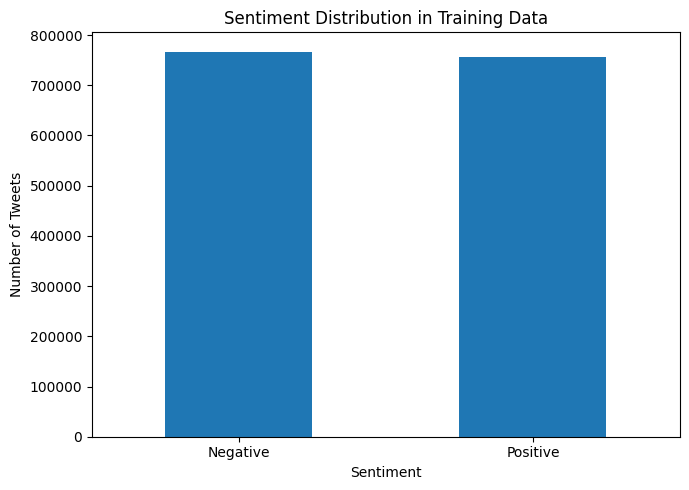

In [21]:
plt.figure(figsize=(7, 5))

train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Sentiment Distribution in Training Data")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(
    ticks=[0, 1],
    labels=["Negative", "Positive"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [22]:
print("Sample negative tweets:")
display(
    train_df[train_df["sentiment"] == 0]["sentence"]
    .head(10)
)

print("\nSample positive tweets:")
display(
    train_df[train_df["sentiment"] == 1]["sentence"]
    .head(10)
)

Sample negative tweets:


0    awww that s a bummer you shoulda got david car...
1    is upset that he can t update his facebook by ...
2    i dived many times for the ball managed to sav...
3       my whole body feels itchy and like its on fire
4    no it s not behaving at all i m mad why am i h...
5                                   not the whole crew
6                                           need a hug
7    hey long time no see yes rains a bit only a bi...
8                             nope they didn t have it
9                                         que me muera
Name: sentence, dtype: object


Sample positive tweets:


767059                             i love u guys r the best
767060    im meeting up with one of my besties tonight c...
767061    thanks for the twitter add sunisa i got to mee...
767062    being sick can be really cheap when it hurts t...
767063                       he has that effect on everyone
767064    you can tell him that i just burst out laughin...
767065    thans for your response ihad already find this...
767066    i am so jealous hope you had a great time in v...
767067    ah congrats mr fletcher for finally joining tw...
767068    i responded stupid cat is helping me type forg...
Name: sentence, dtype: object

In [23]:
duplicate_count = train_df["sentence"].duplicated().sum()

print("Duplicate sentences:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(train_df) * 100, 2),
    "%"
)

Duplicate sentences: 4143
Duplicate percentage: 0.27 %


In [24]:
empty_text = train_df["sentence"].astype(str).str.strip().eq("").sum()

print("Empty training sentences:", empty_text)

empty_test = test_df["sentence"].astype(str).str.strip().eq("").sum()

print("Empty testing sentences:", empty_test)

Empty training sentences: 112
Empty testing sentences: 0


In [25]:
train_df["text_length"] = train_df["sentence"].str.len()

print(train_df["text_length"].describe())

count    1.523975e+06
mean     6.455159e+01
std      3.340908e+01
min      1.000000e+00
25%      3.700000e+01
50%      6.000000e+01
75%      9.100000e+01
max      1.950000e+02
Name: text_length, dtype: float64


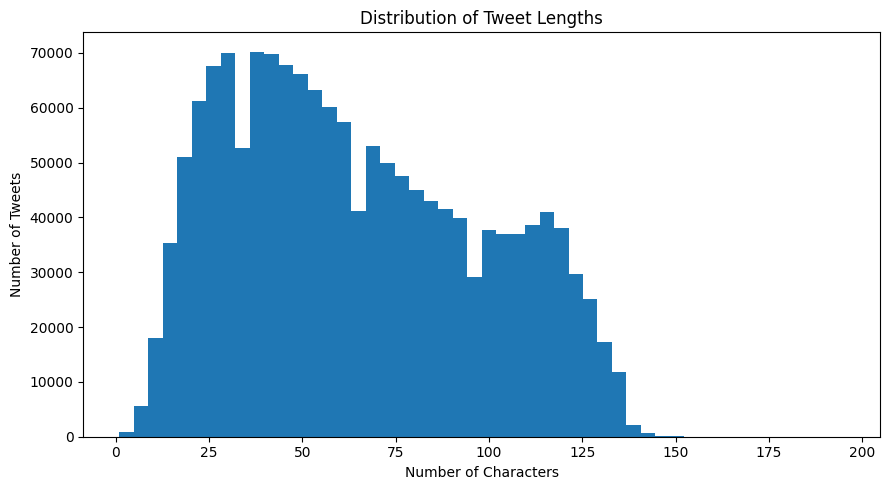

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_df["text_length"],
    bins=50
)

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")

plt.tight_layout()
plt.show()

In [27]:
# Check whether the same sentence appears with different sentiment labels

duplicate_label_check = (
    train_df.groupby("sentence")["sentiment"]
    .nunique()
)

conflicting_duplicates = duplicate_label_check[
    duplicate_label_check > 1
]

print("Sentences with conflicting sentiment labels:",
      len(conflicting_duplicates))

Sentences with conflicting sentiment labels: 4143


In [32]:
# Identify sentences that have conflicting sentiment labels

label_counts = (
    train_df.groupby("sentence")["sentiment"]
    .nunique()
)

conflicting_sentences = label_counts[
    label_counts > 1
].index

print("Conflicting sentences:", len(conflicting_sentences))

# Remove all rows belonging to conflicting sentences
before = len(train_df)

train_df = train_df[
    ~train_df["sentence"].isin(conflicting_sentences)
].copy()

after = len(train_df)

print("Rows before cleaning:", before)
print("Rows after cleaning :", after)
print("Rows removed        :", before - after)

Conflicting sentences: 4109
Rows before cleaning: 1523863
Rows after cleaning : 1515645
Rows removed        : 8218


In [33]:
# Remove empty or whitespace-only sentences

before = len(train_df)

train_df = train_df[
    train_df["sentence"].notna() &
    train_df["sentence"].str.strip().ne("")
].copy()

after = len(train_df)

print("Rows before:", before)
print("Rows after :", after)
print("Empty rows removed:", before - after)

Rows before: 1515645
Rows after : 1515645
Empty rows removed: 0


In [34]:
print("Final training shape:", train_df.shape)

print("\nSentiment distribution:")
print(train_df["sentiment"].value_counts().sort_index())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nConflicting duplicate check:")

remaining_conflicts = (
    train_df.groupby("sentence")["sentiment"]
    .nunique()
)

remaining_conflicts = remaining_conflicts[
    remaining_conflicts > 1
]

print("Remaining conflicting sentences:", len(remaining_conflicts))

Final training shape: (1515645, 2)

Sentiment distribution:
sentiment
0    762914
1    752731
Name: count, dtype: int64

Missing values:
sentence     0
sentiment    0
dtype: int64

Conflicting duplicate check:
Remaining conflicting sentences: 0


In [35]:
print(
    train_df["sentiment"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64


In [38]:
# Separate text and labels

X = train_df["sentence"]
y = train_df["sentiment"]

# Create training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))

Training samples  : 1364080
Validation samples: 151565


In [39]:
print("Training distribution:")
print(
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nValidation distribution:")
print(
    y_val.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Training distribution:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64

Validation distribution:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64


In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [41]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=200000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer created.")

TF-IDF vectorizer created.


In [42]:
print("Fitting TF-IDF on training data...")

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Fitting TF-IDF on training data...
Training TF-IDF shape: (1364080, 200000)


In [43]:
print("Transforming validation data...")

X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Validation TF-IDF shape:", X_val_tfidf.shape)

Transforming validation data...
Validation TF-IDF shape: (151565, 200000)


In [44]:
print("Training matrix:")
print(X_train_tfidf.shape)

print("\nValidation matrix:")
print(X_val_tfidf.shape)

print("\nMatrix type:")
print(type(X_train_tfidf))

print("\nNumber of non-zero values:")
print(X_train_tfidf.nnz)

Training matrix:
(1364080, 200000)

Validation matrix:
(151565, 200000)

Matrix type:
<class 'scipy.sparse._csr.csr_matrix'>

Number of non-zero values:
25910496


In [45]:
from sklearn.linear_model import LogisticRegression

In [46]:
logistic_model = LogisticRegression(
    max_iter=100,
    solver="liblinear",
    random_state=42
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Training complete.")

Training Logistic Regression...
Training complete.


In [47]:
y_val_pred = logistic_model.predict(X_val_tfidf)

print("Predictions generated:", len(y_val_pred))

Predictions generated: 151565


In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Logistic Regression Results")
print("=" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
Accuracy : 0.8204
Precision: 0.8142
Recall   : 0.8270
F1 Score : 0.8206


In [49]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.83      0.81      0.82     76292
    Positive       0.81      0.83      0.82     75273

    accuracy                           0.82    151565
   macro avg       0.82      0.82      0.82    151565
weighted avg       0.82      0.82      0.82    151565



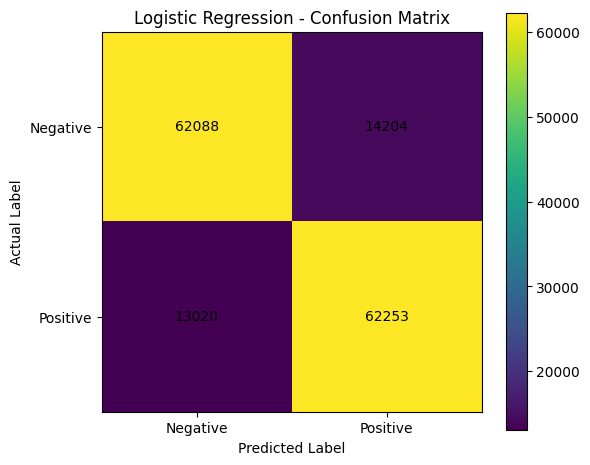

In [50]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [51]:
from sklearn.naive_bayes import MultinomialNB

In [52]:
naive_bayes_model = MultinomialNB()

print("Training Naive Bayes...")

naive_bayes_model.fit(
    X_train_tfidf,
    y_train
)

print("Training complete.")

Training Naive Bayes...
Training complete.


In [53]:
y_val_pred_nb = naive_bayes_model.predict(X_val_tfidf)

print("Predictions generated:", len(y_val_pred_nb))

Predictions generated: 151565


In [54]:
nb_accuracy = accuracy_score(y_val, y_val_pred_nb)
nb_precision = precision_score(y_val, y_val_pred_nb)
nb_recall = recall_score(y_val, y_val_pred_nb)
nb_f1 = f1_score(y_val, y_val_pred_nb)

print("Naive Bayes Results")
print("=" * 40)
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Naive Bayes Results
Accuracy : 0.7987
Precision: 0.8014
Recall   : 0.7907
F1 Score : 0.7960


In [55]:
print(
    classification_report(
        y_val,
        y_val_pred_nb,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.80      0.81      0.80     76292
    Positive       0.80      0.79      0.80     75273

    accuracy                           0.80    151565
   macro avg       0.80      0.80      0.80    151565
weighted avg       0.80      0.80      0.80    151565



In [56]:
from sklearn.svm import LinearSVC

In [57]:
svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=100
)

print("Training Linear SVM...")
svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Training complete.")

Training Linear SVM...
Training complete.


In [58]:
y_val_pred_svm = svm_model.predict(X_val_tfidf)

print("Predictions generated:", len(y_val_pred_svm))

Predictions generated: 151565


In [59]:
svm_accuracy = accuracy_score(y_val, y_val_pred_svm)
svm_precision = precision_score(y_val, y_val_pred_svm)
svm_recall = recall_score(y_val, y_val_pred_svm)
svm_f1 = f1_score(y_val, y_val_pred_svm)

print("Linear SVM Results")
print("=" * 40)
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Linear SVM Results
Accuracy : 0.8121
Precision: 0.8051
Recall   : 0.8202
F1 Score : 0.8126


In [60]:
print(
    classification_report(
        y_val,
        y_val_pred_svm,
        target_names=["Negative", "Positive"]
    )
)

              precision    recall  f1-score   support

    Negative       0.82      0.80      0.81     76292
    Positive       0.81      0.82      0.81     75273

    accuracy                           0.81    151565
   macro avg       0.81      0.81      0.81    151565
weighted avg       0.81      0.81      0.81    151565



In [61]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy
    ],
    "Precision": [
        precision,
        nb_precision,
        svm_precision
    ],
    "Recall": [
        recall,
        nb_recall,
        svm_recall
    ],
    "F1 Score": [
        f1,
        nb_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820381,0.814222,0.827030,0.820576
1,Naive Bayes,0.798733,0.801379,0.790722,0.796015
2,Linear SVM,0.812120,0.805141,0.820201,0.812601


In [62]:
results_display = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_display[column] = (
        results_display[column] * 100
    ).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,82.04,81.42,82.70,82.06
1,Naive Bayes,79.87,80.14,79.07,79.60
2,Linear SVM,81.21,80.51,82.02,81.26


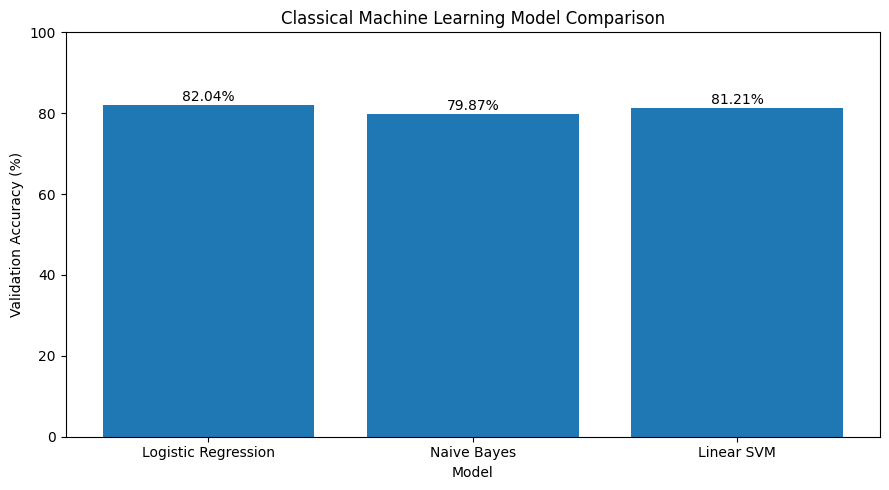

In [63]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"] * 100
)

plt.title("Classical Machine Learning Model Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(results["Accuracy"] * 100):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [64]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [65]:
MAX_WORDS = 50000
MAX_SEQUENCE_LENGTH = 50

EMBEDDING_DIM = 128

print("Maximum vocabulary:", MAX_WORDS)
print("Maximum sequence length:", MAX_SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)

Maximum vocabulary: 50000
Maximum sequence length: 50
Embedding dimension: 128


In [66]:
tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

print("Fitting tokenizer on training text...")
tokenizer.fit_on_texts(X_train)

print("Tokenizer fitted.")
print("Vocabulary size:", len(tokenizer.word_index))

Fitting tokenizer on training text...
Tokenizer fitted.
Vocabulary size: 249154


In [67]:
print("Converting training text...")

X_train_seq = tokenizer.texts_to_sequences(X_train)

print("Converting validation text...")

X_val_seq = tokenizer.texts_to_sequences(X_val)

print("Conversion complete.")

Converting training text...
Converting validation text...
Conversion complete.


In [68]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Training sequence shape:", X_train_pad.shape)
print("Validation sequence shape:", X_val_pad.shape)

Training sequence shape: (1364080, 50)
Validation sequence shape: (151565, 50)


In [70]:
lstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=EMBEDDING_DIM,
        input_shape=(MAX_SEQUENCE_LENGTH,)
    ),

    LSTM(128),
    Dropout(0.5),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,539,905 (24.95 MB)

 Trainable params: 6,539,905 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

In [71]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [72]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=256,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/5
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 1055s 197ms/step - accuracy: 0.7471 - loss: 0.4783 - val_accuracy: 0.8200 - val_loss: 0.3963 - learning_rate: 0.0010
Epoch 2/5
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 1062s 199ms/step - accuracy: 0.8335 - loss: 0.3762 - val_accuracy: 0.8258 - val_loss: 0.3892 - learning_rate: 0.0010
Epoch 3/5
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 1047s 196ms/step - accuracy: 0.8498 - loss: 0.3445 - val_accuracy: 0.8280 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 4/5
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8690 - loss: 0.3063
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 1053s 198ms/step - accuracy: 0.8661 - loss: 0.3120 - val_accuracy: 0.8241 - val_loss: 0.3994 - learning_rate: 0.0010
Epoch 5/5
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8902 - loss: 0.2608
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
5329/5329 ━━━━━━━━━━━━━━━━━━━━ 1054s 198ms/step 

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

lstm_val_probs = lstm_model.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

lstm_val_pred = (lstm_val_probs >= 0.5).astype(int).ravel()

lstm_accuracy = accuracy_score(y_val, lstm_val_pred)
lstm_precision = precision_score(y_val, lstm_val_pred)
lstm_recall = recall_score(y_val, lstm_val_pred)
lstm_f1 = f1_score(y_val, lstm_val_pred)

print("LSTM Validation Results")
print("-----------------------")
print(f"Accuracy : {lstm_accuracy:.4f}")
print(f"Precision: {lstm_precision:.4f}")
print(f"Recall   : {lstm_recall:.4f}")
print(f"F1 Score : {lstm_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    lstm_val_pred,
    target_names=["Negative", "Positive"]
))

593/593 ━━━━━━━━━━━━━━━━━━━━ 80s 134ms/step
LSTM Validation Results
-----------------------
Accuracy : 0.8280
Precision: 0.8313
Recall   : 0.8200
F1 Score : 0.8256

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.84      0.83     76292
    Positive       0.83      0.82      0.83     75273

    accuracy                           0.83    151565
   macro avg       0.83      0.83      0.83    151565
weighted avg       0.83      0.83      0.83    151565



In [74]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "LSTM"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy,
        lstm_accuracy
    ],
    "Precision": [
        precision,
        nb_precision,
        svm_precision,
        lstm_precision
    ],
    "Recall": [
        recall,
        nb_recall,
        svm_recall,
        lstm_recall
    ],
    "F1 Score": [
        f1,
        nb_f1,
        svm_f1,
        lstm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.820381,0.814222,0.827030,0.820576
1,Naive Bayes,0.798733,0.801379,0.790722,0.796015
2,Linear SVM,0.812120,0.805141,0.820201,0.812601
3,LSTM,0.827975,0.831304,0.820028,0.825628


In [75]:
results_percent = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_percent[column] = (
        results_percent[column] * 100
    ).round(2)

results_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,82.04,81.42,82.70,82.06
1,Naive Bayes,79.87,80.14,79.07,79.60
2,Linear SVM,81.21,80.51,82.02,81.26
3,LSTM,82.80,83.13,82.00,82.56


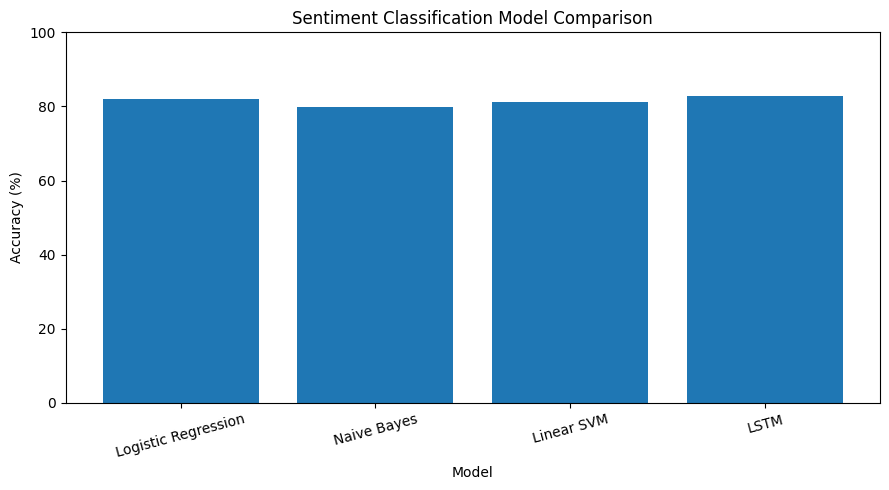

In [76]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Sentiment Classification Model Comparison")
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [78]:
%pip install transformers torch

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.3 MB 5.4 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/12.3 MB 4.4 MB/s eta 0:00:03
   -------- ------------------------------- 2.6/12.3 MB 4.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.4/12.3 MB 4.2 MB/s eta 0:00:03
   ------------- -------------------------- 4.2/12.3 MB 4.1 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/12.3 MB 4.1 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.3 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.3 MB 4.1 MB/s eta 0:00:02
   ------------------------ --------------- 7.6/12.3 MB 4.0 MB/s eta 0:00:02
   --------------------------- ------------ 8.4/12.3 MB 4.0 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 4.0 MB/s eta 0:00:01
   -------------------------------- ------- 10.0/12.3 MB 4.0 MB/s eta 0:00:01
   --


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [79]:
import transformers
import torch

print("Transformers version:", transformers.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Transformers version: 5.17.0
PyTorch version: 2.14.0+cpu
CUDA available: False


In [80]:
from sklearn.model_selection import train_test_split

TRANSFORMER_TRAIN_SIZE = 100_000

X_transformer, _, y_transformer, _ = train_test_split(
    X_train,
    y_train,
    train_size=TRANSFORMER_TRAIN_SIZE,
    random_state=42,
    stratify=y_train
)

print("Transformer training samples:", len(X_transformer))
print("\nClass distribution:")
print(y_transformer.value_counts())
print("\nClass percentages:")
print((y_transformer.value_counts(normalize=True) * 100).round(2))

Transformer training samples: 100000

Class distribution:
sentiment
0    50336
1    49664
Name: count, dtype: int64

Class percentages:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64


In [81]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"

transformer_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Model:", MODEL_NAME)

Tokenizer loaded successfully.
Model: distilbert-base-uncased


In [82]:
MAX_TRANSFORMER_LENGTH = 64

train_encodings = transformer_tokenizer(
    X_transformer.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_TRANSFORMER_LENGTH
)

print("Training tokenization complete.")
print("Number of samples:", len(train_encodings["input_ids"]))
print("Tokens per sample:", len(train_encodings["input_ids"][0]))

Training tokenization complete.
Number of samples: 100000
Tokens per sample: 64


In [83]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


transformer_train_dataset = SentimentDataset(
    train_encodings,
    y_transformer
)

print("Dataset created successfully.")
print("Dataset size:", len(transformer_train_dataset))

sample = transformer_train_dataset[0]
print("\nSample keys:", sample.keys())
print("Input shape:", sample["input_ids"].shape)
print("Label:", sample["labels"].item())

Dataset created successfully.
Dataset size: 100000

Sample keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])
Input shape: torch.Size([64])
Label: 1


In [84]:
from transformers import AutoModelForSequenceClassification

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT model loaded successfully.")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 178.29it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.


In [89]:
TRANSFORMER_VAL_SIZE = 30_000

X_transformer_val, _, y_transformer_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=TRANSFORMER_VAL_SIZE,
    random_state=42,
    stratify=y_val
)

print("Transformer validation samples:", len(X_transformer_val))
print("\nClass distribution:")
print(y_transformer_val.value_counts())

Transformer validation samples: 30000

Class distribution:
sentiment
0    15101
1    14899
Name: count, dtype: int64


In [90]:
val_encodings = transformer_tokenizer(
    X_transformer_val.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_TRANSFORMER_LENGTH
)

print("Validation tokenization complete.")
print("Number of samples:", len(val_encodings["input_ids"]))
print("Tokens per sample:", len(val_encodings["input_ids"][0]))

Validation tokenization complete.
Number of samples: 30000
Tokens per sample: 52


In [91]:
transformer_val_dataset = SentimentDataset(
    val_encodings,
    y_transformer_val
)

print("Validation dataset created successfully.")
print("Dataset size:", len(transformer_val_dataset))

Validation dataset created successfully.
Dataset size: 30000


In [93]:
total_params = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in transformer_model.parameters()
    if parameter.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 66,955,010
Trainable parameters: 66,955,010


In [94]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=transformer_tokenizer,
    padding=True
)

print("Data collator created successfully.")

Data collator created successfully.


In [95]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metric function configured successfully.")

Metric function configured successfully.


In [100]:
import accelerate

print("Accelerate version:", accelerate.__version__)

Accelerate version: 1.15.0


In [102]:
import sys
import importlib.util

print("Python:", sys.executable)
print("Accelerate installed:", importlib.util.find_spec("accelerate") is not None)

if importlib.util.find_spec("accelerate"):
    import accelerate
    print("Accelerate version:", accelerate.__version__)

Python: c:\Users\10cav\AppData\Local\Programs\Python\Python313\python.exe
Accelerate installed: True
Accelerate version: 1.15.0


In [103]:
import transformers
import accelerate
from transformers.utils import is_accelerate_available

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Transformers sees Accelerate:", is_accelerate_available())

Transformers: 5.17.0
Accelerate: 1.15.0
Transformers sees Accelerate: False


In [104]:
import importlib
import transformers.utils.import_utils as import_utils

importlib.reload(import_utils)

print("Transformers sees Accelerate:",
      import_utils.is_accelerate_available())

Transformers sees Accelerate: True


In [106]:
import importlib
import transformers.utils.import_utils as import_utils
import transformers.training_args as training_args_module

# Refresh Accelerate availability
importlib.reload(import_utils)

# Refresh TrainingArguments so it picks up the refreshed availability check
importlib.reload(training_args_module)

from transformers.training_args import TrainingArguments

print("Accelerate available:",
      training_args_module.is_accelerate_available())
print("Accelerate version:", accelerate.__version__)

Accelerate available: False
Accelerate version: 1.15.0


In [107]:
lstm_model.save(
    PROJECT_DIR / "models" / "lstm_sentiment.keras"
)

print("LSTM model saved successfully.")

LSTM model saved successfully.


In [108]:
import pickle

with open(
    PROJECT_DIR / "models" / "lstm_tokenizer.pkl",
    "wb"
) as f:
    pickle.dump(tokenizer, f)

print("LSTM tokenizer saved successfully.")

LSTM tokenizer saved successfully.


In [109]:
import joblib

joblib.dump(
    tfidf_vectorizer,
    PROJECT_DIR / "models" / "tfidf_vectorizer.joblib"
)

joblib.dump(
    logistic_model,
    PROJECT_DIR / "models" / "logistic_regression.joblib"
)

joblib.dump(
    naive_bayes_model,
    PROJECT_DIR / "models" / "naive_bayes.joblib"
)

joblib.dump(
    svm_model,
    PROJECT_DIR / "models" / "linear_svm.joblib"
)

print("Classical models saved successfully.")

Classical models saved successfully.


In [2]:
import os
import re
import csv
import json
import warnings
import pickle
import joblib

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import torch
import transformers
import accelerate

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

warnings.filterwarnings("ignore")

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data" / "sentiment140"
MODEL_DIR = PROJECT_DIR / "models"

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"

print("Environment restored.")
print("Python:", os.sys.executable)
print("Project directory:", PROJECT_DIR)
print("Models directory:", MODEL_DIR)

Environment restored.
Python: c:\Users\10cav\AppData\Local\Programs\Python\Python313\python.exe
Project directory: c:\Users\10cav\Downloads\multilingual-sentiment-analysis
Models directory: c:\Users\10cav\Downloads\multilingual-sentiment-analysis\models


In [3]:
print("Saved model files:")

for file in sorted(MODEL_DIR.iterdir()):
    print("-", file.name)

Saved model files:
- linear_svm.joblib
- logistic_regression.joblib
- lstm_sentiment.keras
- lstm_tokenizer.pkl
- naive_bayes.joblib
- tfidf_vectorizer.joblib


In [4]:
lstm_model = tf.keras.models.load_model(
    MODEL_DIR / "lstm_sentiment.keras"
)

with open(
    MODEL_DIR / "lstm_tokenizer.pkl",
    "rb"
) as f:
    lstm_tokenizer = pickle.load(f)

tfidf_vectorizer = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

logistic_model = joblib.load(
    MODEL_DIR / "logistic_regression.joblib"
)

naive_bayes_model = joblib.load(
    MODEL_DIR / "naive_bayes.joblib"
)

svm_model = joblib.load(
    MODEL_DIR / "linear_svm.joblib"
)

print("All trained models reloaded successfully.")

All trained models reloaded successfully.


In [5]:
train_df = pd.read_csv(
    TRAIN_PATH,
    encoding="utf-8",
    encoding_errors="replace"
)

test_df = pd.read_csv(
    TEST_PATH,
    encoding="utf-8",
    encoding_errors="replace"
)

train_df["sentiment"] = pd.to_numeric(train_df["sentiment"])
test_df["sentiment"] = pd.to_numeric(test_df["sentiment"])

# Remove sentences with conflicting sentiment labels
label_counts = train_df.groupby("sentence")["sentiment"].nunique()
conflicting_sentences = label_counts[label_counts > 1].index

train_df = train_df[
    ~train_df["sentence"].isin(conflicting_sentences)
].copy()

# Remove empty/whitespace-only sentences
train_df = train_df[
    train_df["sentence"].str.strip().ne("")
].copy()

print("Clean training shape:", train_df.shape)
print("Conflicting sentences remaining:",
      train_df.groupby("sentence")["sentiment"].nunique().gt(1).sum())

Clean training shape: (1515645, 2)
Conflicting sentences remaining: 0


In [6]:
X = train_df["sentence"]
y = train_df["sentiment"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nValidation distribution:")
print((y_val.value_counts(normalize=True) * 100).round(2))

Training samples: 1364080
Validation samples: 151565

Training distribution:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64

Validation distribution:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64


In [7]:
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA available:", torch.cuda.is_available())

from transformers.utils import is_accelerate_available

print("Transformers sees Accelerate:",
      is_accelerate_available())

PyTorch: 2.14.0+cpu
Transformers: 5.17.0
Accelerate: 1.15.0
CUDA available: False
Transformers sees Accelerate: True


In [8]:
TRANSFORMER_TRAIN_SIZE = 100_000

X_transformer, _, y_transformer, _ = train_test_split(
    X_train,
    y_train,
    train_size=TRANSFORMER_TRAIN_SIZE,
    random_state=42,
    stratify=y_train
)

print("Transformer training samples:", len(X_transformer))
print("\nClass distribution:")
print(y_transformer.value_counts())

print("\nClass percentages:")
print(
    (y_transformer.value_counts(normalize=True) * 100).round(2)
)

Transformer training samples: 100000

Class distribution:
sentiment
0    50336
1    49664
Name: count, dtype: int64

Class percentages:
sentiment
0    50.34
1    49.66
Name: proportion, dtype: float64


In [9]:
TRANSFORMER_VAL_SIZE = 30_000

X_transformer_val, _, y_transformer_val, _ = train_test_split(
    X_val,
    y_val,
    train_size=TRANSFORMER_VAL_SIZE,
    random_state=42,
    stratify=y_val
)

print("Transformer validation samples:", len(X_transformer_val))
print("\nClass distribution:")
print(y_transformer_val.value_counts())

Transformer validation samples: 30000

Class distribution:
sentiment
0    15101
1    14899
Name: count, dtype: int64


In [10]:
MODEL_NAME = "distilbert-base-uncased"

transformer_tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")
print("Model:", MODEL_NAME)

Tokenizer loaded successfully.
Model: distilbert-base-uncased


In [11]:
MAX_TRANSFORMER_LENGTH = 64

train_encodings = transformer_tokenizer(
    X_transformer.tolist(),
    truncation=True,
    max_length=MAX_TRANSFORMER_LENGTH
)

val_encodings = transformer_tokenizer(
    X_transformer_val.tolist(),
    truncation=True,
    max_length=MAX_TRANSFORMER_LENGTH
)

print("Tokenization complete.")
print("Training samples:", len(train_encodings["input_ids"]))
print("Validation samples:", len(val_encodings["input_ids"]))
print("First training sequence length:",
      len(train_encodings["input_ids"][0]))

Tokenization complete.
Training samples: 100000
Validation samples: 30000
First training sequence length: 21


In [13]:
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)


transformer_train_dataset = SentimentDataset(
    train_encodings,
    y_transformer
)

transformer_val_dataset = SentimentDataset(
    val_encodings,
    y_transformer_val
)

print("Training dataset:", len(transformer_train_dataset))
print("Validation dataset:", len(transformer_val_dataset))

Training dataset: 100000
Validation dataset: 30000


In [14]:
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("DistilBERT model loaded successfully.")

total_params = sum(
    p.numel() for p in transformer_model.parameters()
)

print(f"Total parameters: {total_params:,}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 905.93it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded successfully.
Total parameters: 66,955,010


In [15]:
data_collator = DataCollatorWithPadding(
    tokenizer=transformer_tokenizer,
    padding=True
)

print("Data collator created successfully.")

Data collator created successfully.


In [16]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics configured successfully.")

Metrics configured successfully.


In [17]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./models/distilbert_sentiment",

    num_train_epochs=1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=500,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    report_to="none",

    use_cpu=True
)

print("Training arguments configured successfully.")

Training arguments configured successfully.


In [18]:
from transformers import Trainer

transformer_trainer = Trainer(
    model=transformer_model,
    args=training_args,

    train_dataset=transformer_train_dataset,
    eval_dataset=transformer_val_dataset,

    processing_class=transformer_tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Transformer Trainer created successfully.")

Transformer Trainer created successfully.


In [19]:
transformer_train_result = transformer_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.393184,0.390633,0.832333,0.838513,0.820391,0.829353


NameError: name 'precision_recall_fscore_support' is not defined

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metric function fixed.")

Metric function fixed.


In [21]:
transformer_results = transformer_trainer.evaluate()

print("\nTransformer Validation Results")
print("-----------------------------")

for metric, value in transformer_results.items():
    if metric.startswith("eval_"):
        print(f"{metric}: {value:.4f}")


Transformer Validation Results
-----------------------------
eval_loss: 0.3906
eval_accuracy: 0.8323
eval_precision: 0.8385
eval_recall: 0.8204
eval_f1: 0.8294


In [22]:
TRANSFORMER_MODEL_DIR = MODEL_DIR / "distilbert_sentiment"

TRANSFORMER_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

transformer_trainer.save_model(
    TRANSFORMER_MODEL_DIR
)

transformer_tokenizer.save_pretrained(
    TRANSFORMER_MODEL_DIR
)

print("DistilBERT model and tokenizer saved successfully.")
print("Saved to:", TRANSFORMER_MODEL_DIR)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.64it/s]

DistilBERT model and tokenizer saved successfully.
Saved to: c:\Users\10cav\Downloads\multilingual-sentiment-analysis\models\distilbert_sentiment


In [24]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Linear SVM",
        "Logistic Regression",
        "LSTM",
        "DistilBERT"
    ],
    "Accuracy": [
        0.798733,
        0.812120,
        0.820381,
        0.827975,
        transformer_results["eval_accuracy"]
    ],
    "Precision": [
        0.801379,
        0.805141,
        0.814222,
        0.831304,
        transformer_results["eval_precision"]
    ],
    "Recall": [
        0.790722,
        0.820201,
        0.827030,
        0.820028,
        transformer_results["eval_recall"]
    ],
    "F1 Score": [
        0.796015,
        0.812601,
        0.820576,
        0.825628,
        transformer_results["eval_f1"]
    ]
})

final_results_percent = final_results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    final_results_percent[column] = (
        final_results_percent[column] * 100
    ).round(2)

final_results_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,79.87,80.14,79.07,79.60
1,Linear SVM,81.21,80.51,82.02,81.26
2,Logistic Regression,82.04,81.42,82.70,82.06
3,LSTM,82.80,83.13,82.00,82.56
4,DistilBERT,83.23,83.85,82.04,82.94


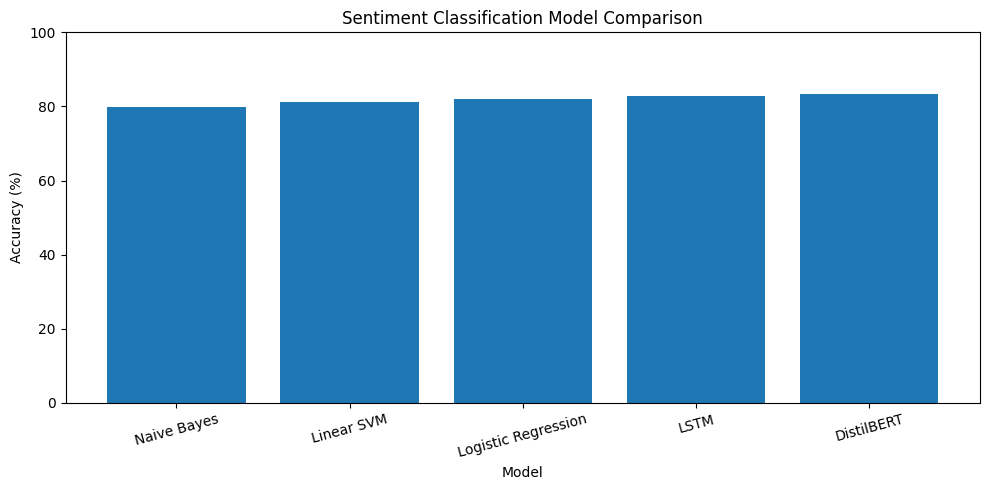

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_results["Model"],
    final_results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Sentiment Classification Model Comparison")
plt.ylim(0, 100)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [26]:
# Load untouched test data
test_df = pd.read_csv(TEST_PATH)

print("Test set shape:", test_df.shape)
print("\nColumns:", test_df.columns.tolist())
print("\nClass distribution:")
print(test_df["sentiment"].value_counts())

Test set shape: (359, 2)

Columns: ['sentence', 'sentiment']

Class distribution:
sentiment
1    182
0    177
Name: count, dtype: int64


In [28]:
import joblib
import tensorflow as tf

# Reload classical models
tfidf_vectorizer = joblib.load(MODEL_DIR / "tfidf_vectorizer.joblib")
naive_bayes = joblib.load(MODEL_DIR / "naive_bayes.joblib")
linear_svm = joblib.load(MODEL_DIR / "linear_svm.joblib")
logistic_regression = joblib.load(MODEL_DIR / "logistic_regression.joblib")

# Reload LSTM
lstm_model = tf.keras.models.load_model(MODEL_DIR / "lstm_sentiment.keras")

with open(MODEL_DIR / "lstm_tokenizer.pkl", "rb") as f:
    lstm_tokenizer = pickle.load(f)

print("All saved models loaded successfully.")

All saved models loaded successfully.


In [30]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Make sure the sequence length is defined
MAX_SEQUENCE_LENGTH = 50

print("LSTM preprocessing ready.")

LSTM preprocessing ready.


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_test = test_df["sentence"].astype(str)
y_test = test_df["sentiment"].astype(int)

test_results = []

# -----------------------------
# 1. Naive Bayes
# -----------------------------
X_test_tfidf = tfidf_vectorizer.transform(X_test)

nb_pred = naive_bayes.predict(X_test_tfidf)

test_results.append({
    "Model": "Naive Bayes",
    "Accuracy": accuracy_score(y_test, nb_pred),
    "Precision": precision_score(y_test, nb_pred),
    "Recall": recall_score(y_test, nb_pred),
    "F1 Score": f1_score(y_test, nb_pred)
})


# -----------------------------
# 2. Linear SVM
# -----------------------------
svm_pred = linear_svm.predict(X_test_tfidf)

test_results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(y_test, svm_pred),
    "Precision": precision_score(y_test, svm_pred),
    "Recall": recall_score(y_test, svm_pred),
    "F1 Score": f1_score(y_test, svm_pred)
})


# -----------------------------
# 3. Logistic Regression
# -----------------------------
lr_pred = logistic_regression.predict(X_test_tfidf)

test_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, lr_pred),
    "Precision": precision_score(y_test, lr_pred),
    "Recall": recall_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
})


# -----------------------------
# 4. LSTM
# -----------------------------
test_sequences = lstm_tokenizer.texts_to_sequences(X_test)

X_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

lstm_prob = lstm_model.predict(X_test_pad, verbose=0)
lstm_pred = (lstm_prob >= 0.5).astype(int).ravel()

test_results.append({
    "Model": "LSTM",
    "Accuracy": accuracy_score(y_test, lstm_pred),
    "Precision": precision_score(y_test, lstm_pred),
    "Recall": recall_score(y_test, lstm_pred),
    "F1 Score": f1_score(y_test, lstm_pred)
})


# -----------------------------
# 5. DistilBERT
# -----------------------------

test_encodings = transformer_tokenizer(
    X_test.tolist(),
    truncation=True,
    max_length=64
)

# Pass y_test directly instead of converting it to a list
test_dataset = SentimentDataset(
    test_encodings,
    y_test
)

transformer_test_output = transformer_trainer.predict(test_dataset)

transformer_pred = transformer_test_output.predictions.argmax(axis=1)

test_results.append({
    "Model": "DistilBERT",
    "Accuracy": accuracy_score(y_test, transformer_pred),
    "Precision": precision_score(y_test, transformer_pred),
    "Recall": recall_score(y_test, transformer_pred),
    "F1 Score": f1_score(y_test, transformer_pred)
})

# Final test-set comparison
test_results_df = pd.DataFrame(test_results)

test_results_percent = test_results_df.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    test_results_percent[column] = (
        test_results_percent[column] * 100
    ).round(2)

test_results_percent

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,82.17,81.72,83.52,82.61
1,Linear SVM,81.06,78.22,86.81,82.29
2,Logistic Regression,81.62,78.71,87.36,82.81
3,LSTM,85.52,83.51,89.01,86.17
4,DistilBERT,85.52,83.51,89.01,86.17


In [33]:
print("LSTM predictions:", len(lstm_pred))
print("DistilBERT predictions:", len(transformer_pred))

print("\nNumber of identical predictions:",
      (lstm_pred == transformer_pred).sum())

print("Total test samples:", len(y_test))

print("\nAre ALL predictions identical?",
      (lstm_pred == transformer_pred).all())

print("\nFirst 30 LSTM predictions:")
print(lstm_pred[:30])

print("\nFirst 30 DistilBERT predictions:")
print(transformer_pred[:30])

LSTM predictions: 359
DistilBERT predictions: 359

Number of identical predictions: 329
Total test samples: 359

Are ALL predictions identical? False

First 30 LSTM predictions:
[1 1 1 1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1]

First 30 DistilBERT predictions:
[1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 0 1 1 1 1 0 1]


In [34]:
# Save validation results
final_results_percent.to_csv(
    MODEL_DIR / "validation_model_comparison.csv",
    index=False
)

# Save untouched test-set results
test_results_percent.to_csv(
    MODEL_DIR / "test_model_comparison.csv",
    index=False
)

print("Results saved successfully.")
print("\nValidation results:")
display(final_results_percent)

print("\nFinal test results:")
display(test_results_percent)

Results saved successfully.

Validation results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,79.87,80.14,79.07,79.60
1,Linear SVM,81.21,80.51,82.02,81.26
2,Logistic Regression,82.04,81.42,82.70,82.06
3,LSTM,82.80,83.13,82.00,82.56
4,DistilBERT,83.23,83.85,82.04,82.94



Final test results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,82.17,81.72,83.52,82.61
1,Linear SVM,81.06,78.22,86.81,82.29
2,Logistic Regression,81.62,78.71,87.36,82.81
3,LSTM,85.52,83.51,89.01,86.17
4,DistilBERT,85.52,83.51,89.01,86.17
